# 📊 EDA Maestro — Predicción de Churn
### Arca Continental · Canal Tradicional México 2024
---
**Datasets fuente:**
- `Clientes.csv` — información estática de cada cliente (territorio, subcanal, tamaño)
- `Coolers.csv` — inventario mensual de enfriadores y puertas por cliente
- `Sales_churn_train.csv` — historial de ventas mensual con variable objetivo `target`
- `Sales_churn_test.csv` — historial de ventas mensual sin `target` (para predicción)
- `preds_submission.csv` — plantilla de entrega de predicciones

**Estructura del notebook:**
1. Importaciones y configuración global
2. Carga y vista general de los datasets
3. Calidad de datos: nulos, tipos y validaciones de negocio
4. Variable objetivo: distribución de churn
5. Dataset integrado (merge)
6. Análisis univariado — variables categóricas
7. Análisis univariado — variables numéricas y outliers
8. Análisis bivariado — variables vs target
9. Análisis bivariado — correlaciones (Spearman y Pearson)
10. Análisis de segmentos de alto riesgo
11. Resumen de hallazgos


## 1. Importaciones y configuración global

In [2]:
# ──────────────────────────────────────────────────────────────
# IMPORTACIONES Y CONFIGURACIÓN GLOBAL
# ──────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from scipy import stats

# ── Estilo unificado para todas las gráficas ──────────────────
plt.rcParams.update({
    'figure.facecolor'  : 'white',
    'axes.facecolor'    : '#f9f9f9',
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'font.family'       : 'DejaVu Sans',
    'axes.titlesize'    : 13,
    'axes.labelsize'    : 11,
    'axes.titleweight'  : 'bold',
})

# Paleta de colores consistente en todo el notebook
COLOR_NO_CHURN = '#4CAF50'   # verde  → cliente retenido (target = 0)
COLOR_CHURN    = '#F44336'   # rojo   → cliente que abandona (target = 1)
COLOR_NEUTRAL  = '#42A5F5'   # azul   → datos sin comparación binaria
COLOR_WARN     = '#FF9800'   # naranja → advertencias o énfasis secundario


## 2. Carga y vista general de los datasets

In [3]:
# ──────────────────────────────────────────────────────────────
# CARGA DE LOS CINCO ARCHIVOS CSV ORIGINALES
# Ajusta las rutas si los archivos no están en el mismo directorio.
# ──────────────────────────────────────────────────────────────
clientes    = pd.read_csv('Clientes.csv')
coolers     = pd.read_csv('Coolers.csv')
sales_train = pd.read_csv('Sales_churn_train.csv')
sales_test  = pd.read_csv('Sales_churn_test.csv')
submission  = pd.read_csv('preds_submission.csv')

# Diccionario auxiliar para iterar sobre los datasets principales
datasets = {
    'clientes'    : clientes,
    'coolers'     : coolers,
    'sales_train' : sales_train,
    'sales_test'  : sales_test,
}


In [4]:
# ──────────────────────────────────────────────────────────────
# VISTA GENERAL: dimensiones, tipos de dato y valores nulos
# Se muestra una sola tabla resumen por dataset (sin duplicar .head()).
# ──────────────────────────────────────────────────────────────
for nombre, df in datasets.items():
    print(f"{'═'*60}")
    print(f"  {nombre.upper()}")
    print(f"{'═'*60}")
    print(f"  Filas: {df.shape[0]:,}  |  Columnas: {df.shape[1]}")
    if 'customer_id' in df.columns:
        print(f"  Clientes únicos: {df['customer_id'].nunique():,}")
    print()

    # Tipos de dato
    print("  Tipos de dato:")
    print(df.dtypes.to_string())
    print()

    # Nulos
    nulls     = df.isnull().sum()
    nulls_pct = (nulls / len(df) * 100).round(2)
    null_df   = pd.DataFrame({'nulos': nulls, '%': nulls_pct})
    tiene_nulos = null_df[null_df['nulos'] > 0]
    if tiene_nulos.empty:
        print("  Valores nulos: ninguno ✓")
    else:
        print("  Valores nulos:")
        print(tiene_nulos.to_string())
    print()


════════════════════════════════════════════════════════════
  CLIENTES
════════════════════════════════════════════════════════════
  Filas: 371,727  |  Columnas: 4
  Clientes únicos: 371,727

  Tipos de dato:
customer_id               object
territory_d               object
comercial_subchannel_d    object
rtm_customer_size_d       object

  Valores nulos:
                     nulos     %
rtm_customer_size_d  15438  4.15

════════════════════════════════════════════════════════════
  COOLERS
════════════════════════════════════════════════════════════
  Filas: 4,636,676  |  Columnas: 4
  Clientes únicos: 208,024

  Tipos de dato:
customer_id     object
calmonth         int64
num_coolers    float64
num_doors        int64

  Valores nulos: ninguno ✓

════════════════════════════════════════════════════════════
  SALES_TRAIN
════════════════════════════════════════════════════════════
  Filas: 5,030,534  |  Columnas: 5
  Clientes únicos: 241,805

  Tipos de dato:
customer_id           o

## 3. Calidad de datos: validaciones de negocio

Se verifican las siguientes reglas de negocio que **deben cumplirse** en los datos:

| Dataset | Regla |
|---------|-------|
| Todos | `calmonth` debe tener formato YYYYMM con mes entre 01 y 12 |
| Coolers | `num_coolers` y `num_doors` ≥ 0; `num_doors` ≥ `num_coolers` |
| Train / Test | `num_transacciones` y `uni_boxes_sold_m` ≥ 0 |
| Train / Test | Si `num_transacciones` > 0 entonces `uni_boxes_sold_m` > 0 |
| Train | `target` solo puede ser 0 o 1 |
| Clientes | Sin duplicados en `customer_id` |


In [5]:
# ──────────────────────────────────────────────────────────────
# FUNCIONES DE VALIDACIÓN DE NEGOCIO
# Cada función imprime un resumen claro de errores encontrados.
# ──────────────────────────────────────────────────────────────

def verificar_calmonth(df, nombre):
    """Valida que la columna calmonth tenga formato YYYYMM con mes 01-12."""
    col = 'calmonth'
    if col not in df.columns:
        return
    mes_str   = df[col].astype(str).str.strip().str.split('.').str[0]
    ultimos2  = mes_str.str[-2:]
    num_mes   = pd.to_numeric(ultimos2, errors='coerce')
    errores   = df[(ultimos2 == '00') | (num_mes > 12) | num_mes.isna()]
    if errores.empty:
        print(f"  ✅ [{nombre}] calmonth sin errores.")
    else:
        print(f"  ❌ [{nombre}] {len(errores)} filas con calmonth inválido.")


def verificar_coolers(df, nombre):
    """Valida que num_coolers y num_doors sean ≥ 0 y que doors ≥ coolers."""
    errores = df[(df['num_coolers'] < 0) | (df['num_doors'] < 0) |
                 (df['num_doors'] < df['num_coolers'])]
    if errores.empty:
        print(f"  ✅ [{nombre}] Coolers sin errores.")
    else:
        n_neg  = ((df['num_coolers'] < 0) | (df['num_doors'] < 0)).sum()
        n_door = (df['num_doors'] < df['num_coolers']).sum()
        print(f"  ❌ [{nombre}] {len(errores)} filas con error.")
        if n_neg  > 0: print(f"       → Valores negativos: {n_neg}")
        if n_door > 0: print(f"       → num_doors < num_coolers: {n_door}")


def verificar_sales(df, nombre, tiene_target=True):
    """Valida transacciones/cajas no negativas y, si aplica, target ∈ {0,1}."""
    col_trans  = 'num_transacciones'
    col_boxes  = 'uni_boxes_sold_m'
    n_neg      = ((df[col_trans] < 0) | (df[col_boxes] < 0)).sum()
    n_cero_box = ((df[col_trans] > 0) & (df[col_boxes] <= 0)).sum()
    n_target   = 0
    if tiene_target:
        n_target = (~df['target'].isin([0, 1])).sum()

    if n_neg == 0 and n_cero_box == 0 and n_target == 0:
        print(f"  ✅ [{nombre}] Sin errores de negocio.")
    else:
        print(f"  ❌ [{nombre}] Errores detectados:")
        if n_neg      > 0: print(f"       → Valores negativos: {n_neg} filas")
        if n_cero_box > 0: print(f"       → Trans > 0 pero cajas = 0: {n_cero_box} filas")
        if n_target   > 0: print(f"       → Target inválido (fuera de 0/1): {n_target} filas")


def verificar_duplicados(df, col, nombre):
    """Verifica que no haya IDs duplicados en una columna clave."""
    n_dup = df.duplicated(subset=[col]).sum()
    if n_dup == 0:
        print(f"  ✅ [{nombre}] Sin duplicados en '{col}'.")
    else:
        print(f"  ❌ [{nombre}] {n_dup} duplicados en '{col}'.")


# ── Ejecución de validaciones ──────────────────────────────────
print("=== VALIDACIÓN CALMONTH ===")
for nombre, df in {'coolers': coolers, 'sales_train': sales_train, 'sales_test': sales_test}.items():
    verificar_calmonth(df, nombre)

print("\n=== VALIDACIÓN COOLERS ===")
verificar_coolers(coolers, 'coolers')

print("\n=== VALIDACIÓN SALES ===")
verificar_sales(sales_train, 'sales_train', tiene_target=True)
verificar_sales(sales_test,  'sales_test',  tiene_target=False)

print("\n=== DUPLICADOS EN CLIENTES ===")
verificar_duplicados(clientes, 'customer_id', 'clientes')


=== VALIDACIÓN CALMONTH ===
  ✅ [coolers] calmonth sin errores.
  ✅ [sales_train] calmonth sin errores.
  ✅ [sales_test] calmonth sin errores.

=== VALIDACIÓN COOLERS ===
  ✅ [coolers] Coolers sin errores.

=== VALIDACIÓN SALES ===
  ❌ [sales_train] Errores detectados:
       → Valores negativos: 79 filas
       → Trans > 0 pero cajas = 0: 645 filas
  ❌ [sales_test] Errores detectados:
       → Valores negativos: 1 filas
       → Trans > 0 pero cajas = 0: 32 filas

=== DUPLICADOS EN CLIENTES ===
  ✅ [clientes] Sin duplicados en 'customer_id'.


In [6]:
# ──────────────────────────────────────────────────────────────
# CONSISTENCIA DE IDs ENTRE ARCHIVOS
# Identifica clientes que aparecen en un solo archivo (huérfanos).
# ──────────────────────────────────────────────────────────────
sets_ids = {
    'clientes'   : set(clientes['customer_id'].astype(str)),
    'coolers'    : set(coolers['customer_id'].astype(str)),
    'sales_train': set(sales_train['customer_id'].astype(str)),
    'sales_test' : set(sales_test['customer_id'].astype(str)),
}

universo = set.union(*sets_ids.values())
print(f"Universo total de customer_id únicos (todos los archivos): {len(universo):,}")
print()

for nombre, ids in sets_ids.items():
    otros   = set.union(*[v for k, v in sets_ids.items() if k != nombre])
    huerfanos = ids - otros
    pct      = len(huerfanos) / len(ids) * 100
    status   = '✅' if len(huerfanos) == 0 else '⚠️ '
    print(f"  {status} {nombre}: {len(ids):,} IDs  |  huérfanos: {len(huerfanos)} ({pct:.1f}%)")


Universo total de customer_id únicos (todos los archivos): 371,727

  ⚠️  clientes: 371,727 IDs  |  huérfanos: 123605 (33.3%)
  ✅ coolers: 208,024 IDs  |  huérfanos: 0 (0.0%)
  ✅ sales_train: 241,805 IDs  |  huérfanos: 0 (0.0%)
  ✅ sales_test: 199,923 IDs  |  huérfanos: 0 (0.0%)


## 4. Variable objetivo: distribución de churn

A nivel de registro (filas en sales_train):
  No churn (0): 4,987,132 (99.14%)
  Churn    (1): 43,402 (0.86%)
  Desbalance:   114.9:1

A nivel de cliente único:
  Total clientes: 241,805
  Churners:       43,402 (17.9%)

  ► Considera usar class_weight='balanced' o SMOTE en el modelo.


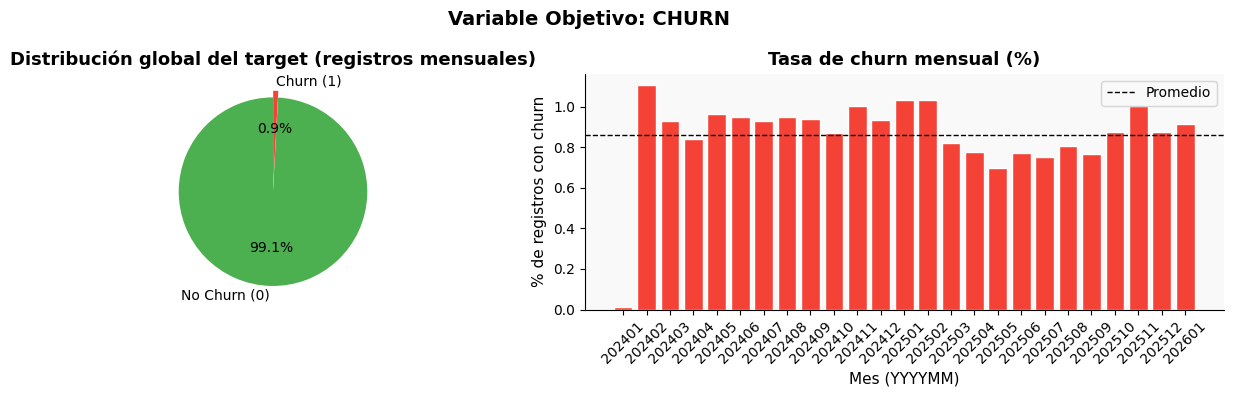

In [7]:
# ──────────────────────────────────────────────────────────────
# DISTRIBUCIÓN DEL TARGET (churn = 1 / no churn = 0)
# Se analiza a nivel de registro mensual y a nivel de cliente único.
# ──────────────────────────────────────────────────────────────
churn_counts = sales_train['target'].value_counts()
churn_pct    = (sales_train['target'].value_counts(normalize=True) * 100).round(2)

print("A nivel de registro (filas en sales_train):")
print(f"  No churn (0): {churn_counts[0]:,} ({churn_pct[0]}%)")
print(f"  Churn    (1): {churn_counts[1]:,} ({churn_pct[1]}%)")
print(f"  Desbalance:   {churn_counts[0]/churn_counts[1]:.1f}:1")
print()

# A nivel cliente único
churn_cliente = sales_train.groupby('customer_id')['target'].max()
n_churners    = churn_cliente.sum()
n_total_cli   = len(churn_cliente)
print("A nivel de cliente único:")
print(f"  Total clientes: {n_total_cli:,}")
print(f"  Churners:       {int(n_churners):,} ({n_churners/n_total_cli*100:.1f}%)")
print()
print("  ► Considera usar class_weight='balanced' o SMOTE en el modelo.")

# ── Gráficas ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Pie chart: proporción global
axes[0].pie(
    churn_counts,
    labels=['No Churn (0)', 'Churn (1)'],
    autopct='%1.1f%%',
    colors=[COLOR_NO_CHURN, COLOR_CHURN],
    startangle=90,
    explode=(0, 0.07),
)
axes[0].set_title('Distribución global del target (registros mensuales)')

# Barras: tasa de churn por mes
churn_por_mes = sales_train.groupby('calmonth')['target'].mean() * 100
axes[1].bar(
    churn_por_mes.index.astype(str),
    churn_por_mes.values,
    color=COLOR_CHURN,
    edgecolor='white',
)
axes[1].axhline(churn_por_mes.mean(), color='black', linestyle='--', linewidth=1, label='Promedio')
axes[1].set_title('Tasa de churn mensual (%)')
axes[1].set_xlabel('Mes (YYYYMM)')
axes[1].set_ylabel('% de registros con churn')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()

plt.suptitle('Variable Objetivo: CHURN', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 5. Dataset integrado (merge)

Se construyen **dos** datasets:

* **`data`** — nivel de registro mensual (train + coolers + clientes): útil para análisis temporales.
* **`df`** — nivel de cliente único (agregación por cliente): útil para correlaciones y segmentación.


In [8]:
# ──────────────────────────────────────────────────────────────
# MERGE A NIVEL MENSUAL
# Útil para análisis que requieren granularidad temporal.
# ──────────────────────────────────────────────────────────────
data = (
    sales_train
    .merge(coolers,   on=['customer_id', 'calmonth'], how='left')
    .merge(clientes,  on='customer_id',               how='left')
)
print(f"Dataset mensual (data): {data.shape[0]:,} filas × {data.shape[1]} columnas")

# ──────────────────────────────────────────────────────────────
# AGREGACIÓN A NIVEL CLIENTE
# Un solo registro por cliente usando estadísticos históricos.
# ──────────────────────────────────────────────────────────────
coolers_agg = coolers.groupby('customer_id').agg(
    avg_coolers=('num_coolers', 'mean'),
    max_coolers=('num_coolers', 'max'),
    avg_doors  =('num_doors',   'mean'),
    max_doors  =('num_doors',   'max'),
).reset_index()

sales_agg = sales_train.groupby('customer_id').agg(
    avg_transacciones =('num_transacciones', 'mean'),
    sum_transacciones =('num_transacciones', 'sum'),
    avg_boxes         =('uni_boxes_sold_m',  'mean'),
    sum_boxes         =('uni_boxes_sold_m',  'sum'),
    meses_activo      =('calmonth',          'nunique'),
    target            =('target',            'max'),   # 1 si churnó alguna vez
).reset_index()

df = (
    sales_agg
    .merge(clientes,    on='customer_id', how='left')
    .merge(coolers_agg, on='customer_id', how='left')
)
print(f"Dataset por cliente (df): {df.shape[0]:,} clientes")
print(f"  Churners: {df['target'].sum():,} ({df['target'].mean()*100:.1f}%)")


Dataset mensual (data): 5,032,039 filas × 10 columnas
Dataset por cliente (df): 241,805 clientes
  Churners: 43,402 (17.9%)


## 6. Análisis univariado — variables categóricas

───────────────────────────────────────────────────────
  TERRITORY_D
───────────────────────────────────────────────────────
                  frecuencia      %
territory_d                        
Guadalajara            45787  12.32
Monterrey              41990  11.30
Jalisco                27156   7.31
Aguascalientes         26178   7.04
Zacatecas              22892   6.16
San Luis Potosi        22516   6.06
Comarca Lagunera       21802   5.87
Culiacan               19076   5.13
Saltillo               16337   4.39
Reynosa                13938   3.75
Juarez                 12137   3.27
Durango                11907   3.20
Mesa Central            9407   2.53
Hermosillo              9272   2.49
Matamoros               9151   2.46
Mazatlan                8299   2.23
Obregon                 8273   2.23
Mexicali                8257   2.22
La Paz                  7998   2.15
Delicias                7461   2.01
Piedras negras          5168   1.39
Monclova                5036   1.35
Chihuahua 

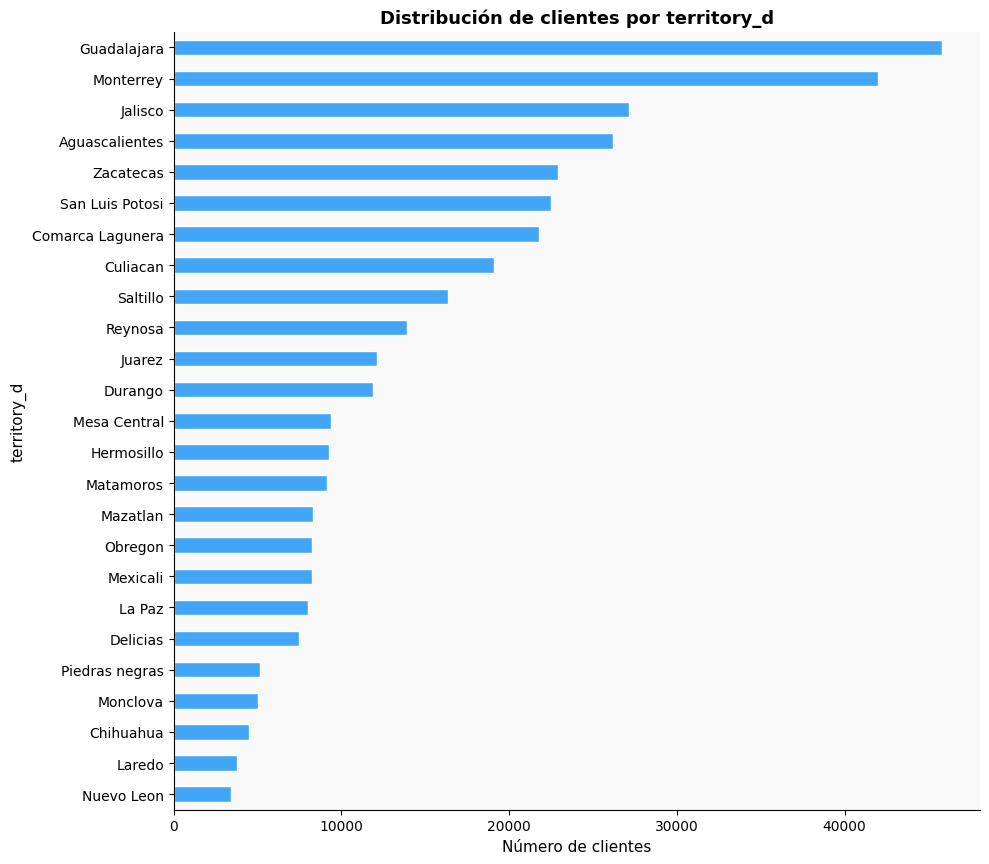

───────────────────────────────────────────────────────
  COMERCIAL_SUBCHANNEL_D
───────────────────────────────────────────────────────
                                frecuencia      %
comercial_subchannel_d                           
Hogares                             128988  34.70
Abarrotes y bodegas                  86562  23.29
Kiosco                               75969  20.44
Licorería                            31498   8.47
Verdulería                           12236   3.29
Farmacia                              6893   1.85
Tiendas de carne/pollo/pescado        6885   1.85
Tienda orgánica                       6148   1.65
Tortillería                           6104   1.64
Minisuper                             4487   1.21
Panadería                             2907   0.78
Mayorista                             2228   0.60
Proximidad                             822   0.22



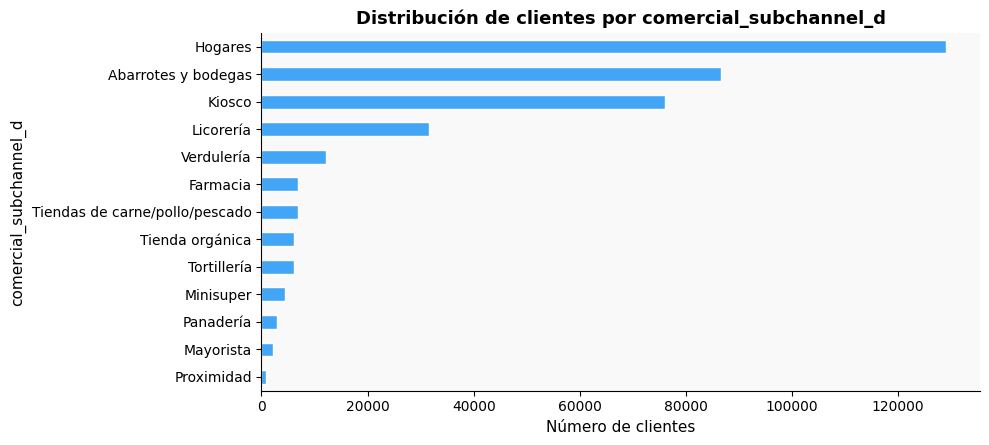

───────────────────────────────────────────────────────
  RTM_CUSTOMER_SIZE_D
───────────────────────────────────────────────────────
                     frecuencia      %
rtm_customer_size_d                   
Mini                     148489  41.68
Mediano                   85947  24.12
Pequeño                   80974  22.73
Grande                    25241   7.08
Gigante                   15638   4.39



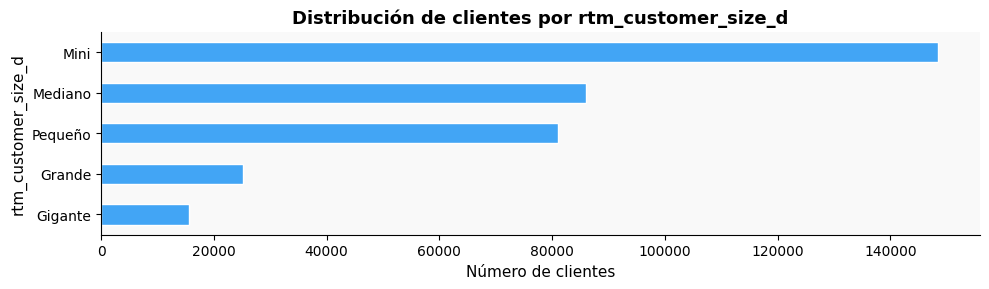

In [9]:
# ──────────────────────────────────────────────────────────────
# DISTRIBUCIÓN DE LAS TRES VARIABLES CATEGÓRICAS DEL DATASET
# Se muestra la frecuencia absoluta y relativa de cada categoría.
# ──────────────────────────────────────────────────────────────
categoricas = ['territory_d', 'comercial_subchannel_d', 'rtm_customer_size_d']

for col in categoricas:
    print(f"{'─'*55}")
    print(f"  {col.upper()}")
    print(f"{'─'*55}")
    freq = clientes[col].value_counts()
    pct  = (clientes[col].value_counts(normalize=True) * 100).round(2)
    tabla = pd.DataFrame({'frecuencia': freq, '%': pct})
    print(tabla.to_string())
    print()

    # Gráfica de barras horizontales
    fig, ax = plt.subplots(figsize=(10, max(3, len(freq) * 0.35)))
    freq.plot(kind='barh', ax=ax, color=COLOR_NEUTRAL, edgecolor='white')
    ax.set_title(f'Distribución de clientes por {col}')
    ax.set_xlabel('Número de clientes')
    ax.set_ylabel(col)
    ax.invert_yaxis()          # la categoría más frecuente queda arriba
    plt.tight_layout()
    plt.show()


## 7. Análisis univariado — variables numéricas y outliers

In [10]:
# ──────────────────────────────────────────────────────────────
# ESTADÍSTICAS DESCRIPTIVAS DE VARIABLES NUMÉRICAS
# Incluye histograma, boxplot y detección de outliers por IQR.
# ──────────────────────────────────────────────────────────────
vars_num_coolers = ['num_coolers', 'num_doors']
vars_num_sales   = ['num_transacciones', 'uni_boxes_sold_m']

print("ESTADÍSTICAS — COOLERS")
print(coolers[vars_num_coolers].describe().round(2))
print()
print("ESTADÍSTICAS — SALES TRAIN")
print(sales_train[vars_num_sales].describe().round(2))


ESTADÍSTICAS — COOLERS
       num_coolers   num_doors
count   4636676.00  4636676.00
mean          1.55        2.32
std           1.24        1.89
min           1.00        1.00
25%           1.00        1.00
50%           1.00        2.00
75%           2.00        3.00
max         212.00      306.00

ESTADÍSTICAS — SALES TRAIN
       num_transacciones  uni_boxes_sold_m
count         5030534.00        5030534.00
mean               94.72            247.91
std                84.66            342.24
min                 0.00          -1298.59
25%                34.00             66.78
50%                69.00            151.30
75%               131.00            316.48
max              1842.00          31062.04


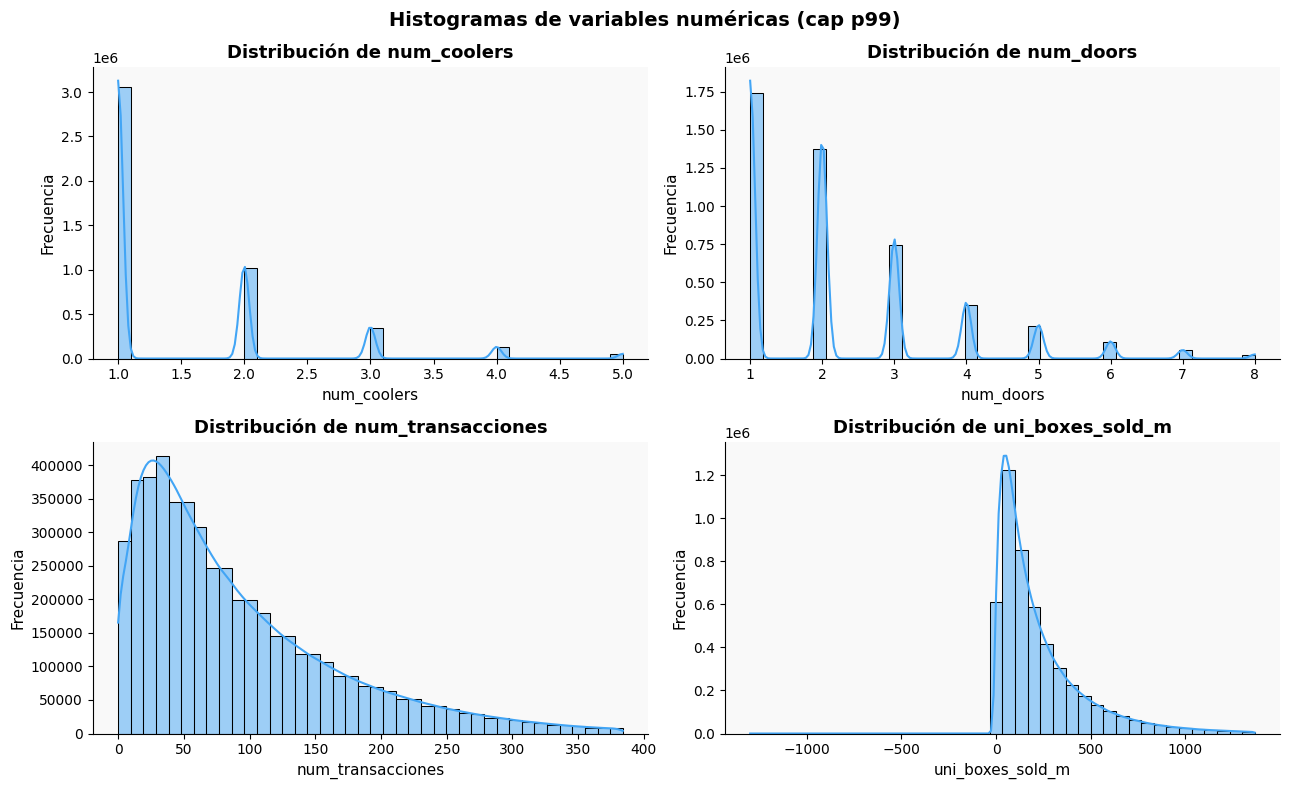

In [11]:
# ──────────────────────────────────────────────────────────────
# HISTOGRAMAS CON CURVA KDE
# Muestran la forma de la distribución de cada variable numérica.
# ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

for ax, (col, fuente) in zip(axes.flat, [
    ('num_coolers',        coolers),
    ('num_doors',          coolers),
    ('num_transacciones',  sales_train),
    ('uni_boxes_sold_m',   sales_train),
]):
    serie = fuente[col].dropna()
    cap   = serie.quantile(0.99)          # cap al p99 para mejor visualización
    sns.histplot(serie[serie <= cap], bins=40, kde=True, ax=ax, color=COLOR_NEUTRAL)
    ax.set_title(f'Distribución de {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frecuencia')

plt.suptitle('Histogramas de variables numéricas (cap p99)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [12]:
# ──────────────────────────────────────────────────────────────
# DETECCIÓN DE OUTLIERS MEDIANTE IQR
# Se reporta la tasa de churn dentro de los outliers vs global.
# ──────────────────────────────────────────────────────────────
def reporte_outliers(serie, nombre, df_con_target=None):
    """
    Calcula límites IQR y reporta cuántos outliers hay.
    Si se provee df_con_target, también muestra la tasa de churn en outliers.
    """
    Q1, Q3 = serie.quantile(0.25), serie.quantile(0.75)
    IQR    = Q3 - Q1
    lim_inf, lim_sup = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    mask   = (serie < lim_inf) | (serie > lim_sup)
    n_out  = mask.sum()
    pct    = n_out / len(serie) * 100
    print(f"  {nombre}:")
    print(f"    Q1={Q1:.2f}  Q3={Q3:.2f}  IQR={IQR:.2f}  "
          f"Límites=[{lim_inf:.2f}, {lim_sup:.2f}]")
    print(f"    Outliers: {n_out:,} ({pct:.1f}%)")
    if df_con_target is not None and n_out > 0:
        churn_out = df_con_target.loc[mask.values[:len(df_con_target)], 'target'].mean() * 100
        churn_glb = df_con_target['target'].mean() * 100
        print(f"    Churn en outliers: {churn_out:.1f}%  (vs {churn_glb:.1f}% global)")
    print()

print("OUTLIERS EN COOLERS")
reporte_outliers(coolers['num_coolers'], 'num_coolers')
reporte_outliers(coolers['num_doors'],   'num_doors')

print("OUTLIERS EN SALES TRAIN")
reporte_outliers(sales_train['num_transacciones'], 'num_transacciones', sales_train)
reporte_outliers(sales_train['uni_boxes_sold_m'],  'uni_boxes_sold_m',  sales_train)


OUTLIERS EN COOLERS
  num_coolers:
    Q1=1.00  Q3=2.00  IQR=1.00  Límites=[-0.50, 3.50]
    Outliers: 217,761 (4.7%)

  num_doors:
    Q1=1.00  Q3=3.00  IQR=2.00  Límites=[-2.00, 6.00]
    Outliers: 108,744 (2.3%)

OUTLIERS EN SALES TRAIN
  num_transacciones:
    Q1=34.00  Q3=131.00  IQR=97.00  Límites=[-111.50, 276.50]
    Outliers: 217,417 (4.3%)
    Churn en outliers: 0.0%  (vs 0.9% global)

  uni_boxes_sold_m:
    Q1=66.78  Q3=316.48  IQR=249.71  Límites=[-307.78, 691.04]
    Outliers: 331,618 (6.6%)
    Churn en outliers: 0.0%  (vs 0.9% global)



## 8. Análisis bivariado — variables vs target (churn)

### 8a. Variables categóricas vs churn

───────────────────────────────────────────────────────
  TERRITORY_D
───────────────────────────────────────────────────────
                  clientes  % del total  churners  tasa_churn_%
territory_d                                                    
Monclova              3131          1.3       811         25.90
Reynosa               7666          3.2      1983         25.87
Matamoros             5220          2.2      1189         22.78
Guadalajara          31613         13.1      7003         22.15
Laredo                2211          0.9       487         22.03
Saltillo              7585          3.1      1663         21.92
San Luis Potosi      15587          6.4      3267         20.96
Comarca Lagunera     12929          5.3      2680         20.73
Piedras negras        4045          1.7       807         19.95
Culiacan             11533          4.8      2253         19.54
Monterrey            25214         10.4      4918         19.51
Hermosillo            5762          2.4   

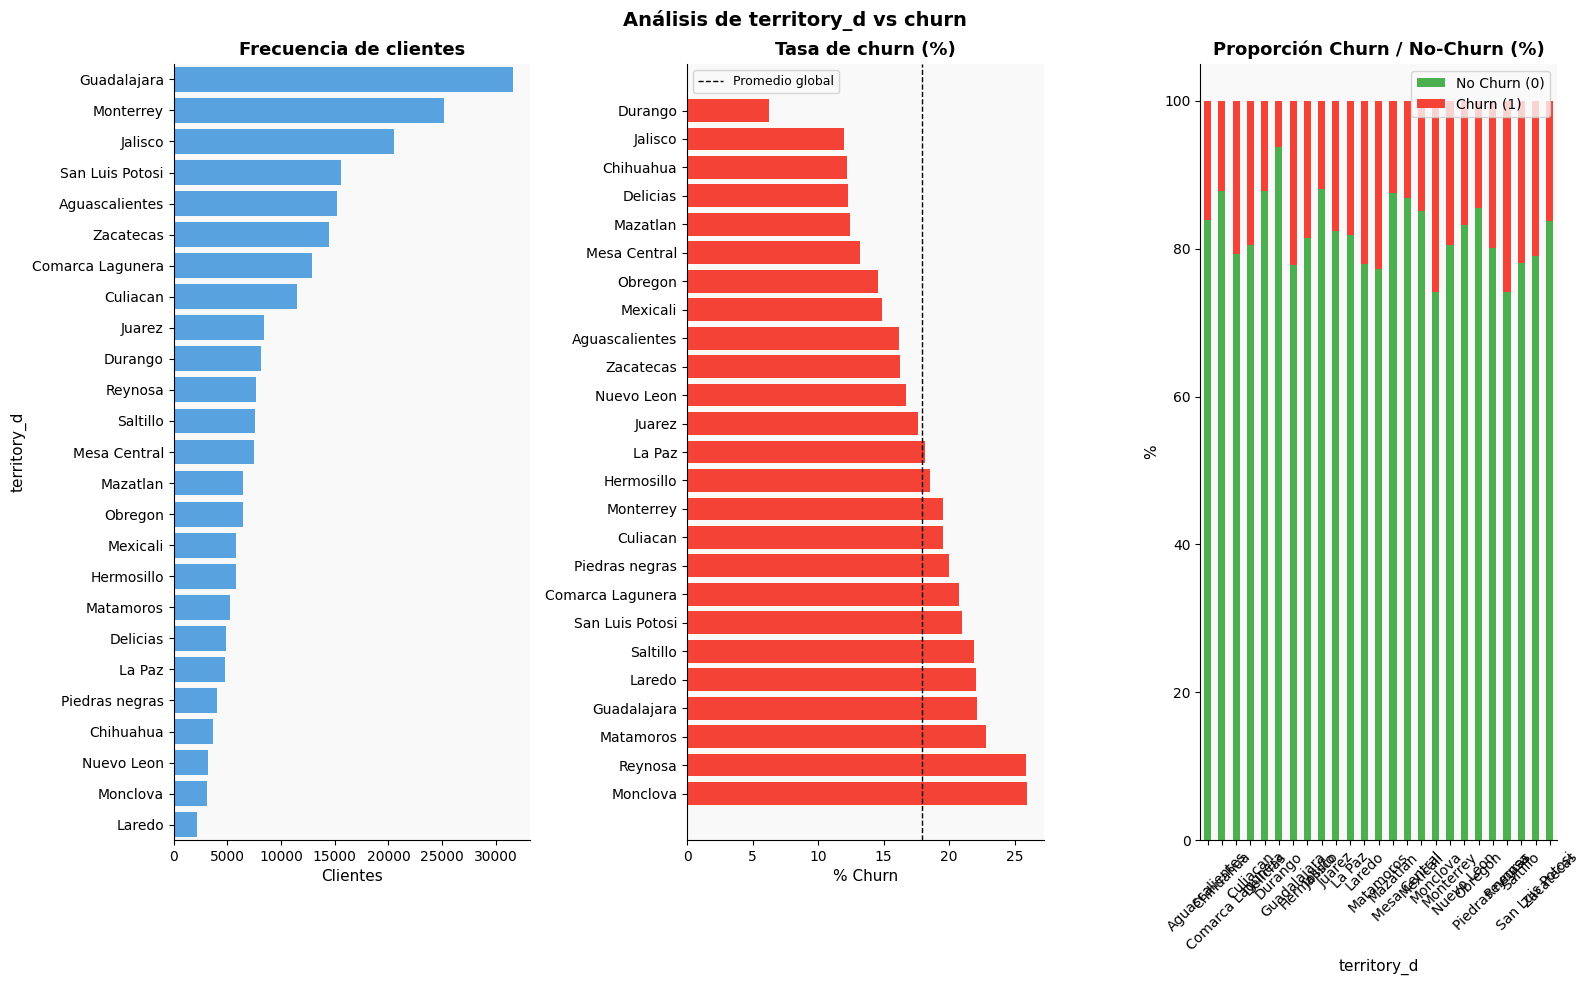

───────────────────────────────────────────────────────
  COMERCIAL_SUBCHANNEL_D
───────────────────────────────────────────────────────
                                clientes  % del total  churners  tasa_churn_%
comercial_subchannel_d                                                       
Hogares                            68679         28.4     18129         26.40
Tienda orgánica                     3861          1.6       732         18.96
Verdulería                          8890          3.7      1602         18.02
Farmacia                            4841          2.0       867         17.91
Panadería                           1901          0.8       326         17.15
Tortillería                         4243          1.8       713         16.80
Abarrotes y bodegas                61066         25.3      9572         15.67
Tiendas de carne/pollo/pescado      4913          2.0       761         15.49
Licorería                          23122          9.6      3415         14.77
Kiosc

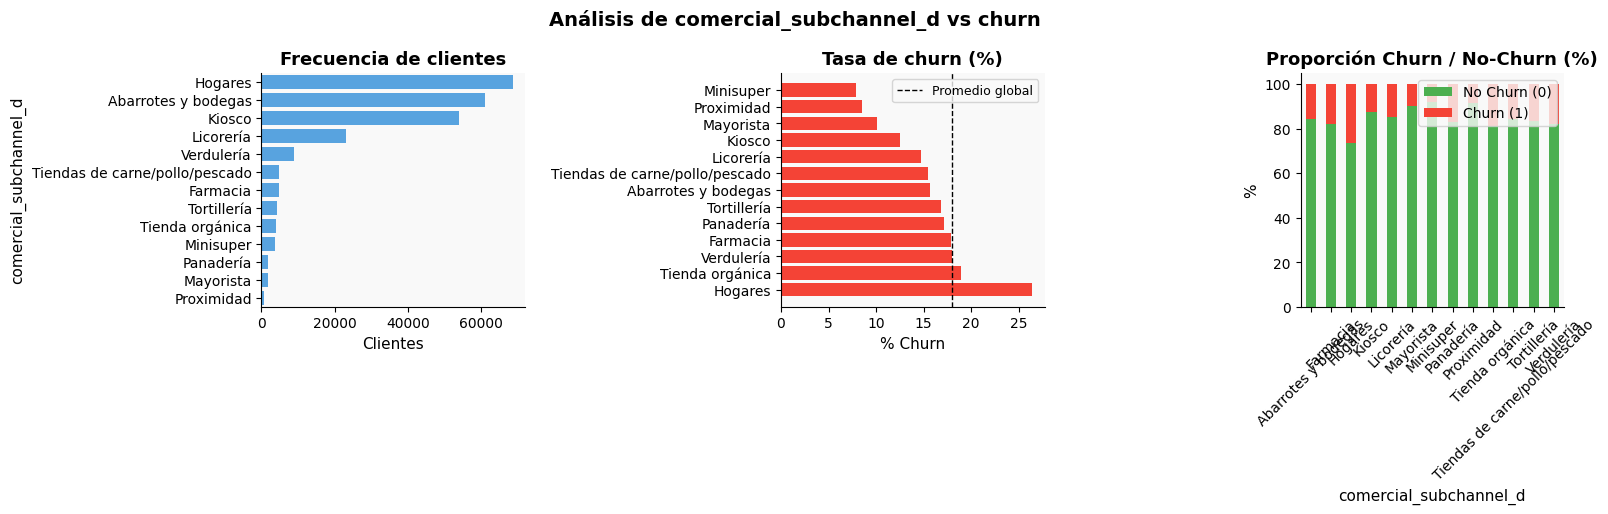

───────────────────────────────────────────────────────
  RTM_CUSTOMER_SIZE_D
───────────────────────────────────────────────────────
                     clientes  % del total  churners  tasa_churn_%
rtm_customer_size_d                                               
Mini                    60511         25.0     31690         52.37
Pequeño                 63547         26.3      8149         12.82
Mediano                 78916         32.6      3182          4.03
Grande                  23691          9.8       265          1.12
Gigante                 15140          6.3       116          0.77



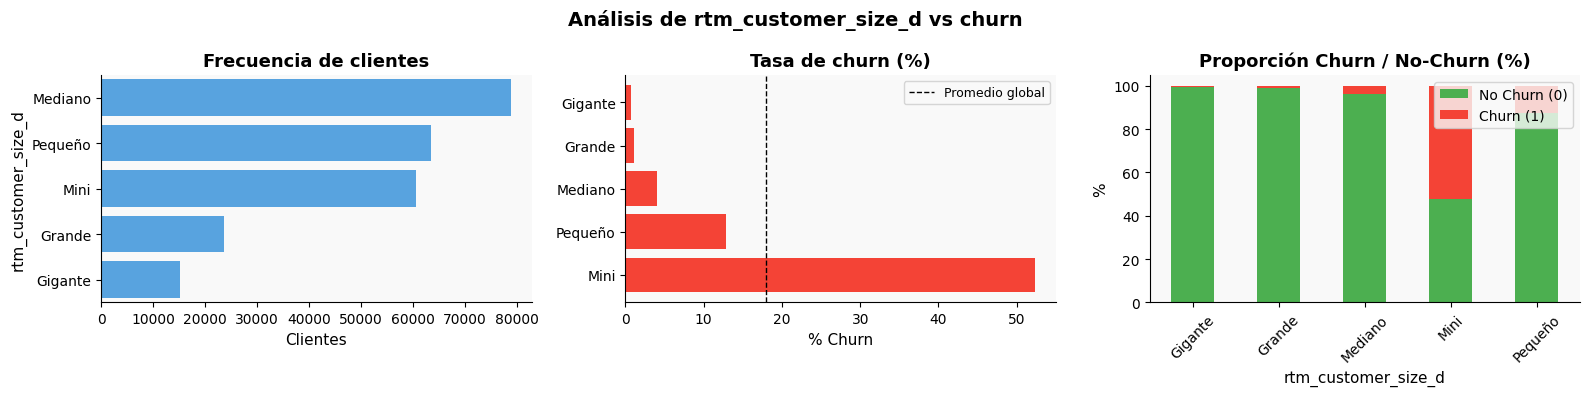

In [13]:
# ──────────────────────────────────────────────────────────────
# VARIABLES CATEGÓRICAS VS CHURN
# Para cada variable se muestra:
#   1. Tabla: conteo y tasa de churn por categoría
#   2. Gráfica triple: frecuencia · tasa de churn · proporción apilada
# ──────────────────────────────────────────────────────────────
for col in categoricas:
    print(f"{'─'*55}")
    print(f"  {col.upper()}")
    print(f"{'─'*55}")

    # Tabla resumen
    tabla = df.groupby(col)['target'].agg(
        clientes  ='count',
        churners  ='sum',
        tasa_churn='mean',
    ).sort_values('tasa_churn', ascending=False)
    tabla['tasa_churn_%'] = (tabla['tasa_churn'] * 100).round(2)
    tabla['% del total']  = (tabla['clientes'] / tabla['clientes'].sum() * 100).round(1)
    print(tabla[['clientes', '% del total', 'churners', 'tasa_churn_%']].to_string())
    print()

    # Gráfica triple
    fig, axes = plt.subplots(1, 3, figsize=(16, max(4, len(tabla) * 0.4)))

    # Panel 1: frecuencia de clientes
    order = df[col].value_counts().index
    sns.countplot(data=df, y=col, order=order, ax=axes[0], color=COLOR_NEUTRAL)
    axes[0].set_title('Frecuencia de clientes')
    axes[0].set_xlabel('Clientes')
    axes[0].set_ylabel(col)

    # Panel 2: tasa de churn por categoría (barras horizontales)
    tasa = df.groupby(col)['target'].mean().sort_values(ascending=False) * 100
    axes[1].barh(tasa.index, tasa.values, color=COLOR_CHURN)
    axes[1].axvline(df['target'].mean() * 100, color='black',
                    linestyle='--', linewidth=1, label='Promedio global')
    axes[1].set_title('Tasa de churn (%)')
    axes[1].set_xlabel('% Churn')
    axes[1].legend(fontsize=9)

    # Panel 3: proporción churn / no-churn apilada (%)
    ct = pd.crosstab(df[col], df['target'], normalize='index') * 100
    ct.plot(kind='bar', stacked=True, ax=axes[2],
            color=[COLOR_NO_CHURN, COLOR_CHURN])
    axes[2].set_title('Proporción Churn / No-Churn (%)')
    axes[2].set_ylabel('%')
    axes[2].tick_params(axis='x', rotation=45)
    axes[2].legend(['No Churn (0)', 'Churn (1)'], loc='upper right')

    plt.suptitle(f'Análisis de {col} vs churn', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


### 8b. Variables numéricas vs churn

Test Mann-Whitney U (p < 0.05 → diferencia significativa entre grupos):

  avg_transacciones               p=0.0000  *** SIGNIFICATIVO
  avg_boxes                       p=0.0000  *** SIGNIFICATIVO
  meses_activo                    p=0.0000  *** SIGNIFICATIVO
  avg_coolers                     p=0.0000  *** SIGNIFICATIVO
  avg_doors                       p=0.0000  *** SIGNIFICATIVO



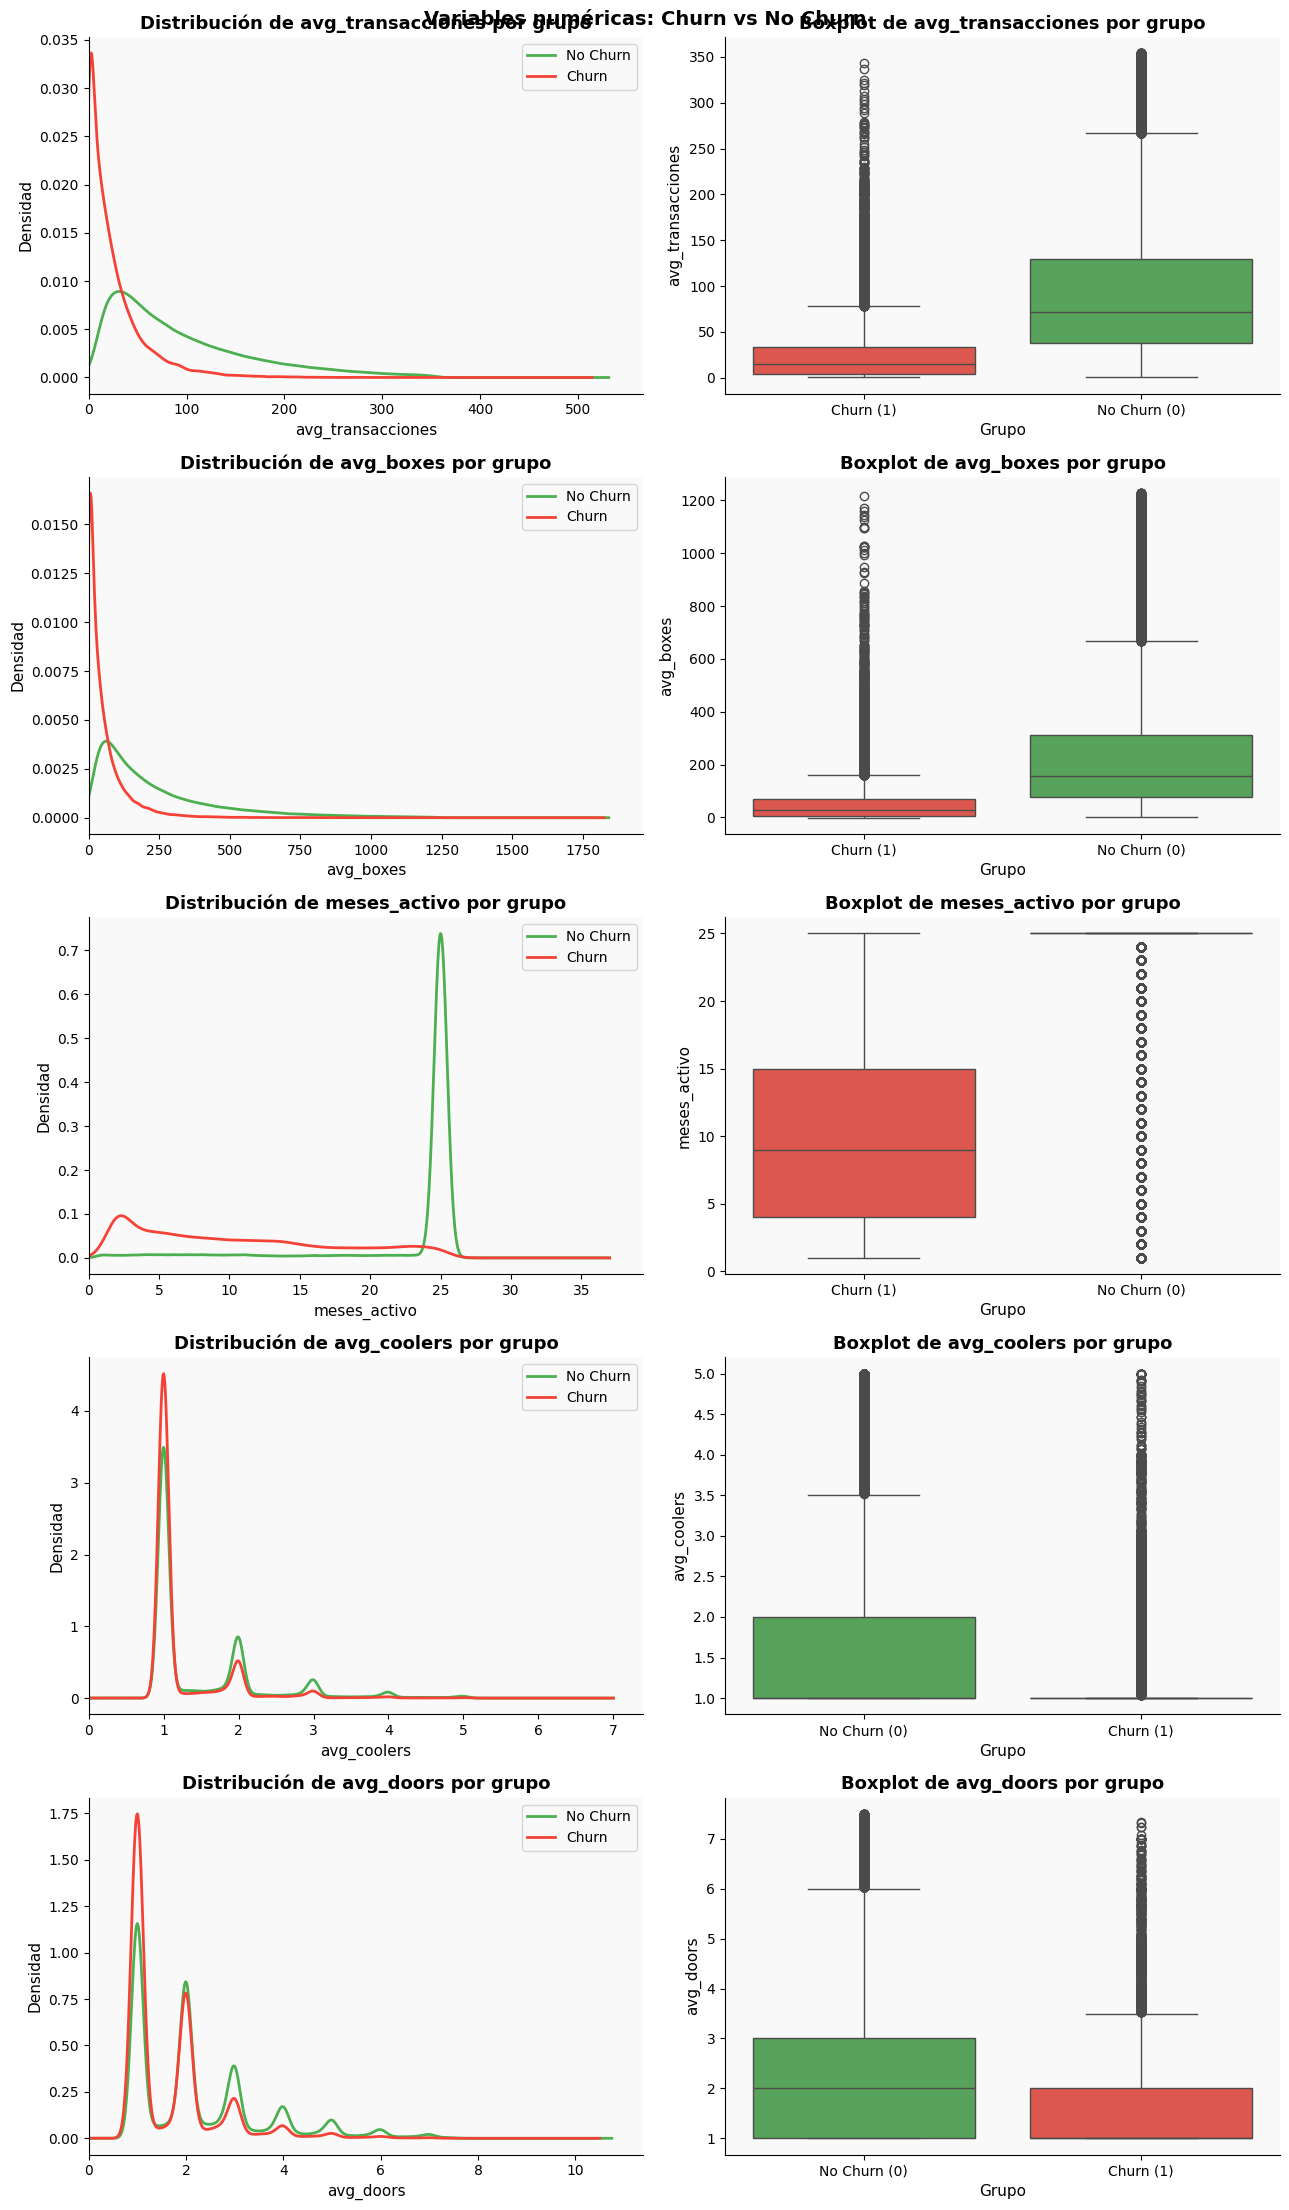

In [14]:
# ──────────────────────────────────────────────────────────────
# DISTRIBUCIÓN DE VARIABLES NUMÉRICAS AGREGADAS POR GRUPO (churn vs no-churn)
# KDE + boxplot para cada variable, con test Mann-Whitney para significancia.
# ──────────────────────────────────────────────────────────────
vars_num_df = ['avg_transacciones', 'avg_boxes', 'meses_activo',
               'avg_coolers', 'avg_doors']

print("Test Mann-Whitney U (p < 0.05 → diferencia significativa entre grupos):")
print()

for col in vars_num_df:
    churn_vals    = df[df['target'] == 1][col].dropna()
    no_churn_vals = df[df['target'] == 0][col].dropna()
    _, p_val      = stats.mannwhitneyu(churn_vals, no_churn_vals, alternative='two-sided')
    sig = '*** SIGNIFICATIVO' if p_val < 0.05 else '(no significativo)'
    print(f"  {col:30s}  p={p_val:.4f}  {sig}")

print()

# Gráfica: KDE + boxplot para cada variable numérica
fig, axes = plt.subplots(len(vars_num_df), 2,
                         figsize=(13, 4.5 * len(vars_num_df)))

for i, col in enumerate(vars_num_df):
    cap = df[col].quantile(0.99)        # cap p99 para visualización limpia

    # KDE por grupo
    for label, color, etiqueta in [(0, COLOR_NO_CHURN, 'No Churn'),
                                    (1, COLOR_CHURN,    'Churn')]:
        subset = df[df['target'] == label][col].dropna()
        subset[subset <= cap].plot.kde(
            ax=axes[i, 0], color=color, label=etiqueta, linewidth=2)
    axes[i, 0].set_title(f'Distribución de {col} por grupo')
    axes[i, 0].set_xlabel(col)
    axes[i, 0].set_ylabel('Densidad')
    axes[i, 0].legend()
    axes[i, 0].set_xlim(left=0)

    # Boxplot comparativo
    df_plot = df[df[col] <= cap].copy()
    df_plot['target_str'] = df_plot['target'].map({0: 'No Churn (0)', 1: 'Churn (1)'})
    sns.boxplot(data=df_plot, x='target_str', y=col,
                palette={'No Churn (0)': COLOR_NO_CHURN, 'Churn (1)': COLOR_CHURN},
                ax=axes[i, 1])
    axes[i, 1].set_title(f'Boxplot de {col} por grupo')
    axes[i, 1].set_xlabel('Grupo')
    axes[i, 1].set_ylabel(col)

plt.suptitle('Variables numéricas: Churn vs No Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### 8c. Análisis específico: coolers y meses activos vs churn

Promedio de coolers por tamaño de cliente:
                     promedio_coolers  mediana_coolers
rtm_customer_size_d                                   
Gigante                          2.87              2.0
Grande                           2.11              2.0
Mediano                          1.55              1.0
Pequeño                          1.19              1.0
Mini                             1.11              1.0



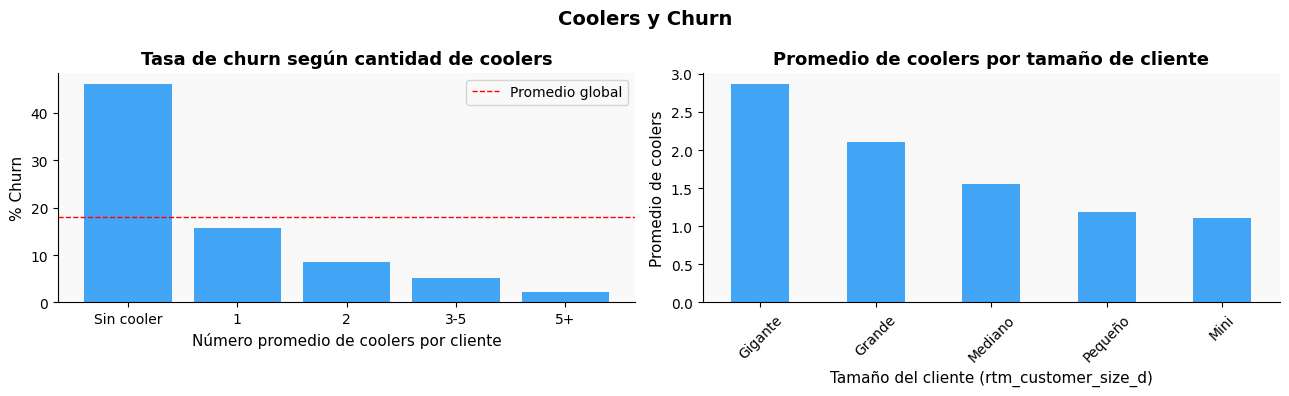

In [15]:
# ──────────────────────────────────────────────────────────────
# COOLERS VS CHURN
# ¿Tener más coolers reduce el riesgo de abandono?
# ──────────────────────────────────────────────────────────────
df['bins_coolers'] = pd.cut(
    df['avg_coolers'].fillna(0),
    bins=[-0.1, 0, 1, 2, 5, 100],
    labels=['Sin cooler', '1', '2', '3-5', '5+']
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Tasa de churn por número de coolers (agrupado)
tasa_cooler = df.groupby('bins_coolers')['target'].mean() * 100
axes[0].bar(tasa_cooler.index.astype(str), tasa_cooler.values, color=COLOR_NEUTRAL)
axes[0].axhline(df['target'].mean() * 100, color='red',
                linestyle='--', linewidth=1, label='Promedio global')
axes[0].set_title('Tasa de churn según cantidad de coolers')
axes[0].set_xlabel('Número promedio de coolers por cliente')
axes[0].set_ylabel('% Churn')
axes[0].legend()

# Churn por tamaño de cliente y promedio de coolers
resumen_cooler = (
    coolers.merge(clientes[['customer_id', 'rtm_customer_size_d']], on='customer_id', how='left')
    .groupby('rtm_customer_size_d').agg(
        promedio_coolers=('num_coolers', 'mean'),
        mediana_coolers =('num_coolers', 'median'),
    ).round(2).sort_values('promedio_coolers', ascending=False)
)
print("Promedio de coolers por tamaño de cliente:")
print(resumen_cooler.to_string())
print()

# Barras: coolers promedio por tamaño
resumen_cooler['promedio_coolers'].plot(kind='bar', ax=axes[1], color=COLOR_NEUTRAL)
axes[1].set_title('Promedio de coolers por tamaño de cliente')
axes[1].set_xlabel('Tamaño del cliente (rtm_customer_size_d)')
axes[1].set_ylabel('Promedio de coolers')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Coolers y Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


Promedio de cajas vendidas por tamaño de cliente:
rtm_customer_size_d  promedio_boxes
            Gigante     1005.811750
             Grande      490.450671
            Mediano      229.272805
            Pequeño       88.236385
               Mini       33.018920



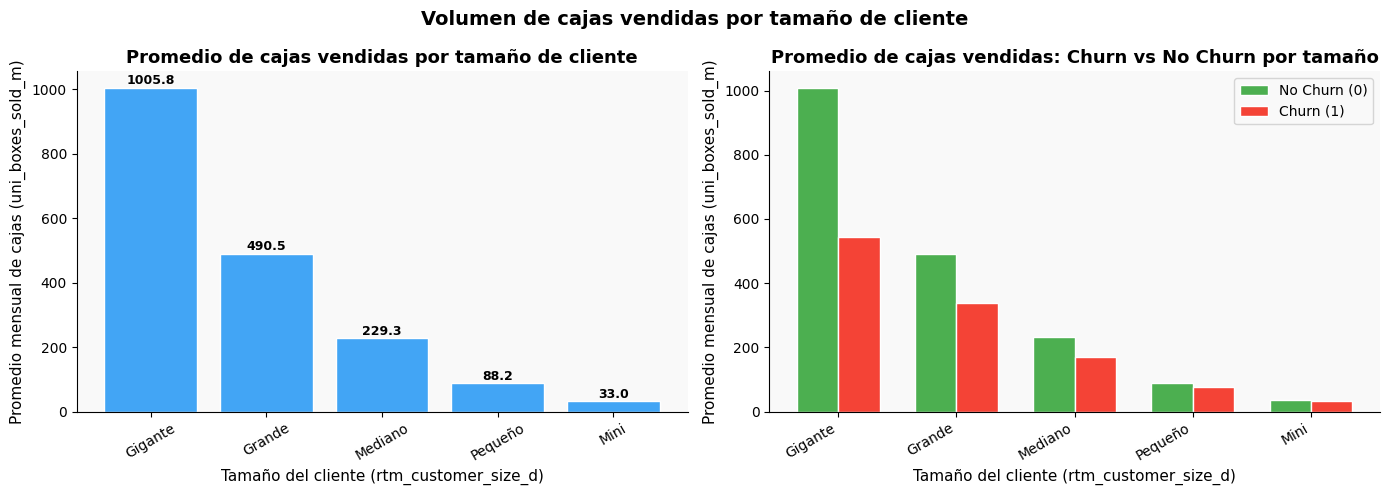

In [16]:
# ──────────────────────────────────────────────────────────────
# PROMEDIO DE CAJAS VENDIDAS (uni_boxes_sold_m) POR TAMAÑO DE CLIENTE
# Muestra cuántas cajas vende en promedio cada segmento de cliente,
# separando clientes con churn (target=1) y sin churn (target=0).
# ──────────────────────────────────────────────────────────────

# Calcular promedio de cajas por tamaño de cliente y por grupo de churn
resumen_boxes = (
    df.groupby(['rtm_customer_size_d', 'target'])['avg_boxes']
    .mean()
    .reset_index()
    .rename(columns={'avg_boxes': 'promedio_boxes'})
)
resumen_boxes['target_str'] = resumen_boxes['target'].map({0: 'No Churn (0)', 1: 'Churn (1)'})

# También calcular el promedio global por tamaño (sin separar por churn)
resumen_global = (
    df.groupby('rtm_customer_size_d')['avg_boxes']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={'avg_boxes': 'promedio_boxes'})
)

print("Promedio de cajas vendidas por tamaño de cliente:")
print(resumen_global.to_string(index=False))
print()

# ── Gráfica doble ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: promedio global de cajas por tamaño de cliente
orden = resumen_global['rtm_customer_size_d'].tolist()
axes[0].bar(
    resumen_global['rtm_customer_size_d'],
    resumen_global['promedio_boxes'],
    color=COLOR_NEUTRAL,
    edgecolor='white',
)
# Etiquetas de valor encima de cada barra
for bar in axes[0].patches:
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f"{bar.get_height():.1f}",
        ha='center', va='bottom', fontsize=9, fontweight='bold',
    )
axes[0].set_title('Promedio de cajas vendidas por tamaño de cliente')
axes[0].set_xlabel('Tamaño del cliente (rtm_customer_size_d)')
axes[0].set_ylabel('Promedio mensual de cajas (uni_boxes_sold_m)')
axes[0].tick_params(axis='x', rotation=30)

# Panel 2: comparación Churn vs No Churn por tamaño de cliente
pivot_boxes = resumen_boxes.pivot(
    index='rtm_customer_size_d',
    columns='target_str',
    values='promedio_boxes',
).reindex(orden)

x     = range(len(pivot_boxes))
width = 0.35

# Barras agrupadas: No Churn y Churn lado a lado
bars_no_churn = axes[1].bar(
    [i - width/2 for i in x],
    pivot_boxes.get('No Churn (0)', 0),
    width=width,
    label='No Churn (0)',
    color=COLOR_NO_CHURN,
    edgecolor='white',
)
bars_churn = axes[1].bar(
    [i + width/2 for i in x],
    pivot_boxes.get('Churn (1)', 0),
    width=width,
    label='Churn (1)',
    color=COLOR_CHURN,
    edgecolor='white',
)

axes[1].set_xticks(list(x))
axes[1].set_xticklabels(pivot_boxes.index, rotation=30, ha='right')
axes[1].set_title('Promedio de cajas vendidas: Churn vs No Churn por tamaño')
axes[1].set_xlabel('Tamaño del cliente (rtm_customer_size_d)')
axes[1].set_ylabel('Promedio mensual de cajas (uni_boxes_sold_m)')
axes[1].legend()

plt.suptitle('Volumen de cajas vendidas por tamaño de cliente', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


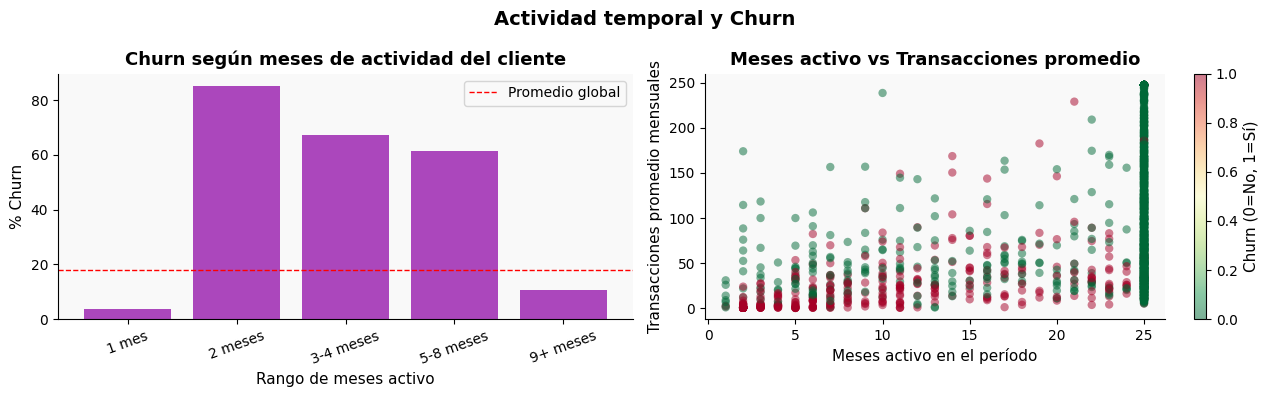

In [17]:
# ──────────────────────────────────────────────────────────────
# MESES ACTIVOS VS CHURN
# Los clientes más recientes (menos meses activos), ¿churnan más?
# ──────────────────────────────────────────────────────────────
df['bins_meses'] = pd.cut(
    df['meses_activo'],
    bins=[0, 1, 2, 4, 8, 50],
    labels=['1 mes', '2 meses', '3-4 meses', '5-8 meses', '9+ meses']
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Tasa de churn por rango de meses activos
tasa_meses = df.groupby('bins_meses')['target'].mean() * 100
axes[0].bar(tasa_meses.index.astype(str), tasa_meses.values, color='#AB47BC')
axes[0].axhline(df['target'].mean() * 100, color='red',
                linestyle='--', linewidth=1, label='Promedio global')
axes[0].set_title('Churn según meses de actividad del cliente')
axes[0].set_xlabel('Rango de meses activo')
axes[0].set_ylabel('% Churn')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=20)

# Scatter: meses activo vs transacciones promedio, coloreado por churn
sample = df.sample(min(2000, len(df)), random_state=42)
cap_trans = sample['avg_transacciones'].quantile(0.95)
sc = axes[1].scatter(
    sample['meses_activo'],
    sample['avg_transacciones'].clip(upper=cap_trans),
    c=sample['target'],
    cmap='RdYlGn_r',
    alpha=0.5,
    edgecolors='none',
)
plt.colorbar(sc, ax=axes[1], label='Churn (0=No, 1=Sí)')
axes[1].set_title('Meses activo vs Transacciones promedio')
axes[1].set_xlabel('Meses activo en el período')
axes[1].set_ylabel('Transacciones promedio mensuales')

plt.suptitle('Actividad temporal y Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### 8d. Churn por número de transacciones y cajas vendidas

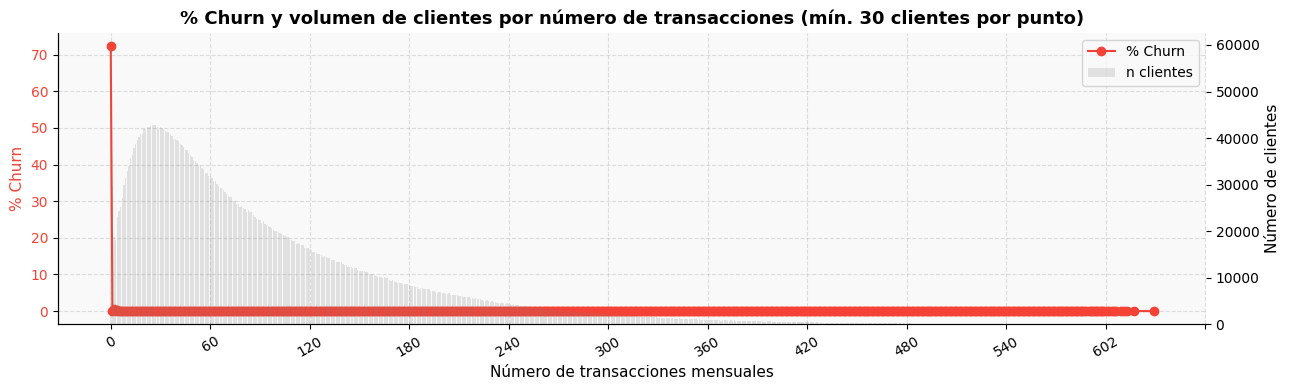

In [18]:
# ──────────────────────────────────────────────────────────────
# % CHURN POR NÚMERO DE TRANSACCIONES MENSUALES
# Se filtran grupos con menos de 30 clientes para evitar ruido estadístico.
# Eje secundario muestra el volumen de clientes en cada punto.
# ──────────────────────────────────────────────────────────────
MIN_CLIENTES = 30  # umbral mínimo para incluir un valor en la gráfica

tabla_trans = (
    data.groupby('num_transacciones')['target']
    .agg(clientes='count', churners='sum', pct_churn='mean')
    .reset_index()
)
tabla_trans['pct_churn'] *= 100
tabla_trans = tabla_trans[tabla_trans['clientes'] >= MIN_CLIENTES].sort_values('num_transacciones')

fig, ax1 = plt.subplots(figsize=(13, 4))

# Línea: tasa de churn
ax1.plot(tabla_trans['num_transacciones'], tabla_trans['pct_churn'],
         marker='o', color=COLOR_CHURN, label='% Churn')
ax1.set_xlabel('Número de transacciones mensuales')
ax1.set_ylabel('% Churn', color=COLOR_CHURN)
ax1.set_title(f'% Churn y volumen de clientes por número de transacciones '
              f'(mín. {MIN_CLIENTES} clientes por punto)')
ax1.tick_params(axis='y', labelcolor=COLOR_CHURN)
ax1.xaxis.set_major_locator(ticker.MaxNLocator(nbins=12, integer=True))
ax1.tick_params(axis='x', rotation=30)
ax1.grid(True, linestyle='--', alpha=0.4)

# Barras: volumen de clientes (eje secundario)
ax2 = ax1.twinx()
ax2.bar(tabla_trans['num_transacciones'].astype(str),
        tabla_trans['clientes'], alpha=0.20, color='gray', label='n clientes')
ax2.set_ylabel('Número de clientes')
ax2.tick_params(axis='x', rotation=30)

# Leyenda combinada
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.show()


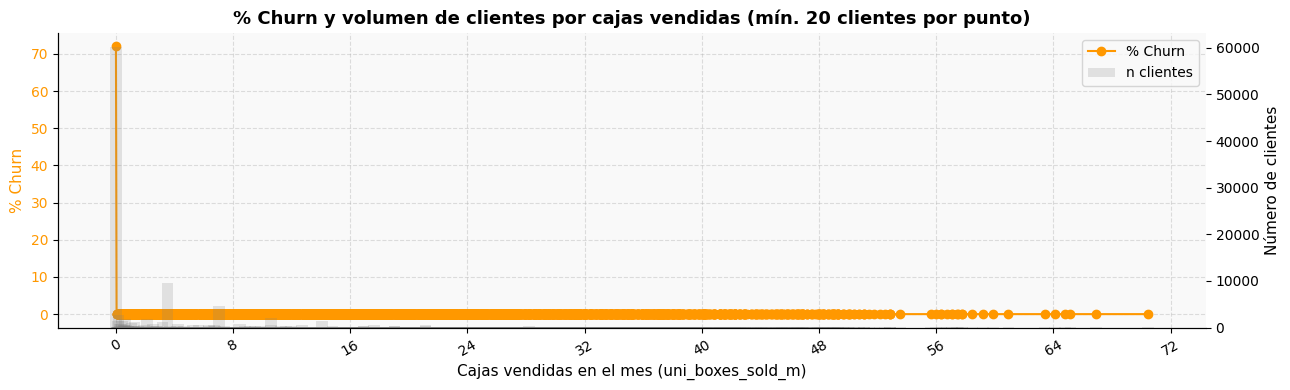

In [19]:
# ──────────────────────────────────────────────────────────────
# % CHURN POR NÚMERO DE CAJAS VENDIDAS
# Misma lógica que la gráfica anterior pero para uni_boxes_sold_m.
# ──────────────────────────────────────────────────────────────
tabla_cajas = (
    data.groupby('uni_boxes_sold_m')['target']
    .agg(clientes='count', churners='sum', pct_churn='mean')
    .reset_index()
)
tabla_cajas['pct_churn'] *= 100
tabla_cajas = tabla_cajas[tabla_cajas['clientes'] >= 20].sort_values('uni_boxes_sold_m')

fig, ax1 = plt.subplots(figsize=(13, 4))

ax1.plot(tabla_cajas['uni_boxes_sold_m'], tabla_cajas['pct_churn'],
         marker='o', color=COLOR_WARN, label='% Churn')
ax1.set_xlabel('Cajas vendidas en el mes (uni_boxes_sold_m)')
ax1.set_ylabel('% Churn', color=COLOR_WARN)
ax1.set_title('% Churn y volumen de clientes por cajas vendidas (mín. 20 clientes por punto)')
ax1.tick_params(axis='y', labelcolor=COLOR_WARN)
ax1.xaxis.set_major_locator(ticker.MaxNLocator(nbins=12, integer=True))
ax1.tick_params(axis='x', rotation=30)
ax1.grid(True, linestyle='--', alpha=0.4)

ax2 = ax1.twinx()
ax2.bar(tabla_cajas['uni_boxes_sold_m'],
        tabla_cajas['clientes'], alpha=0.20, color='gray', label='n clientes')
ax2.set_ylabel('Número de clientes')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.show()


## 9. Correlaciones con el target

In [20]:
# ──────────────────────────────────────────────────────────────
# CORRELACIÓN DE SPEARMAN (nivel mensual)
# Spearman es más robusta ante distribuciones no normales y outliers.
# Se calcula sobre el dataset mensual integrado (data).
# ──────────────────────────────────────────────────────────────
cols_spearman = ['calmonth', 'num_transacciones', 'uni_boxes_sold_m',
                 'num_coolers', 'num_doors', 'target']

spearman = (
    data[cols_spearman]
    .corr(method='spearman')['target']
    .drop('target')
    .sort_values(key=abs, ascending=False)
    .to_frame('spearman_corr')
)
print("Correlación de Spearman con target (nivel mensual):")
print(spearman.round(4).to_string())


Correlación de Spearman con target (nivel mensual):
                   spearman_corr
uni_boxes_sold_m         -0.1596
num_transacciones        -0.1596
num_doors                -0.0201
num_coolers              -0.0140
calmonth                  0.0019


In [21]:
# ──────────────────────────────────────────────────────────────
# CORRELACIÓN DE SPEARMAN (nivel cliente agregado)
# Usando el dataset df (un registro por cliente).
# ──────────────────────────────────────────────────────────────
cols_corr_cli = ['avg_transacciones', 'sum_transacciones',
                 'avg_boxes', 'sum_boxes', 'meses_activo',
                 'avg_coolers', 'max_coolers', 'avg_doors', 'target']

corr_cli = (
    df[cols_corr_cli]
    .corr(method='spearman')['target']
    .drop('target')
    .sort_values(key=abs, ascending=False)
)
print("Correlación de Spearman con target (nivel cliente):")
print(corr_cli.round(4).to_string())


Correlación de Spearman con target (nivel cliente):
meses_activo        -0.7072
sum_transacciones   -0.5345
sum_boxes           -0.5305
avg_transacciones   -0.4755
avg_boxes           -0.4754
avg_doors           -0.1592
max_coolers         -0.1277
avg_coolers         -0.1274


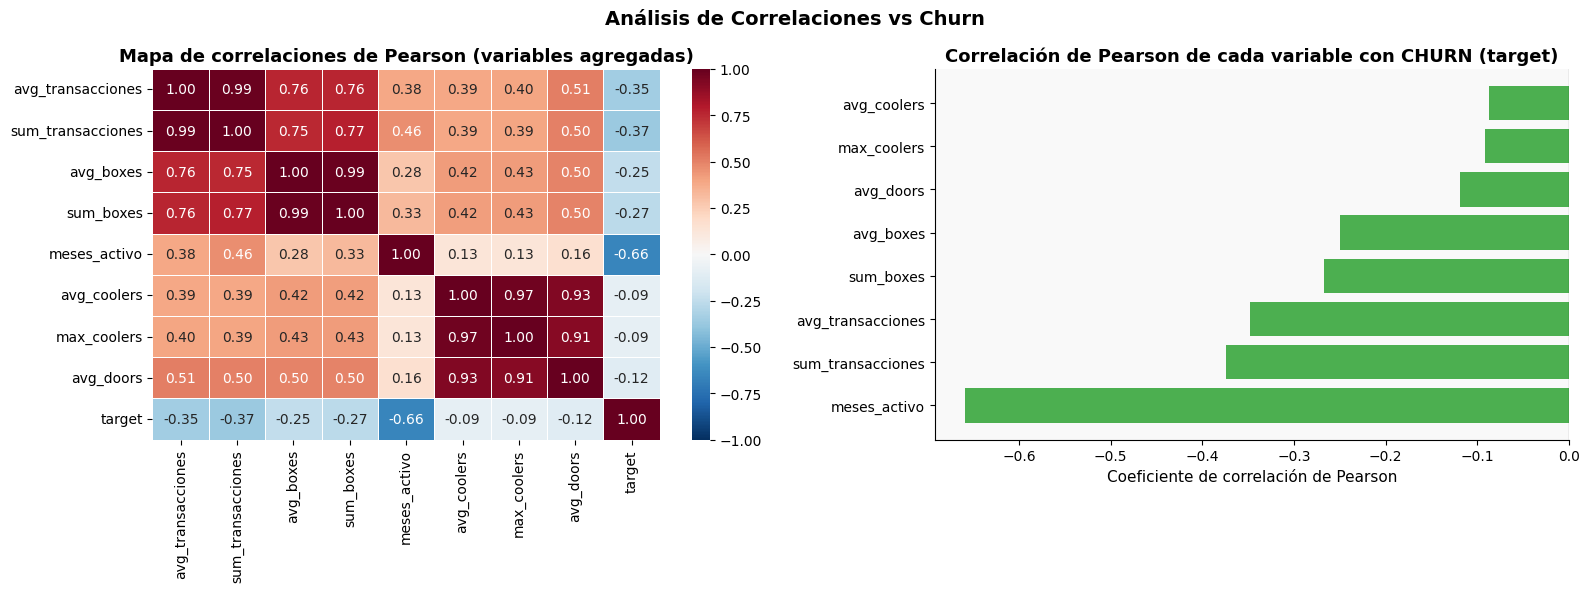

In [22]:
# ──────────────────────────────────────────────────────────────
# MAPA DE CORRELACIONES (Pearson) Y BARRAS DE CORRELACIÓN
# Se usa Pearson para el heatmap estándar; los resultados
# deben interpretarse junto con los de Spearman.
# ──────────────────────────────────────────────────────────────
vars_heatmap = ['avg_transacciones', 'sum_transacciones',
                'avg_boxes', 'sum_boxes', 'meses_activo',
                'avg_coolers', 'max_coolers', 'avg_doors', 'target']

corr_matrix  = df[vars_heatmap].corr()
corr_target  = corr_matrix['target'].drop('target').sort_values()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap
sns.heatmap(
    corr_matrix,
    annot=True, fmt='.2f', cmap='RdBu_r',
    center=0, vmin=-1, vmax=1,
    linewidths=0.5, ax=axes[0],
)
axes[0].set_title('Mapa de correlaciones de Pearson (variables agregadas)')

# Barras de correlación con target
colors = [COLOR_CHURN if v > 0 else COLOR_NO_CHURN for v in corr_target.values]
axes[1].barh(corr_target.index, corr_target.values, color=colors)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Correlación de Pearson de cada variable con CHURN (target)')
axes[1].set_xlabel('Coeficiente de correlación de Pearson')

plt.suptitle('Análisis de Correlaciones vs Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 10. Segmentos de alto riesgo

Tasa de churn (%) por Tamaño × Territorio:
territory_d          Aguascalientes  Chihuahua  Comarca Lagunera  Culiacan  Delicias  Durango  Guadalajara  Hermosillo  Jalisco  Juarez  La Paz  Laredo  Matamoros  Mazatlan  Mesa Central  Mexicali  Monclova  Monterrey  Nuevo Leon  Obregon  Piedras negras  Reynosa  Saltillo  San Luis Potosi  Zacatecas
rtm_customer_size_d                                                                                                                                                                                                                                                                                          
Gigante                         0.6        1.1               0.8       0.0       4.2      0.8          0.4         0.6      0.4     1.2     3.7     0.0        0.5       0.0           0.0       0.2       5.8        0.9         0.4      0.0             0.7      0.6       0.6              0.4        1.7
Grande                          0.7        1.1     

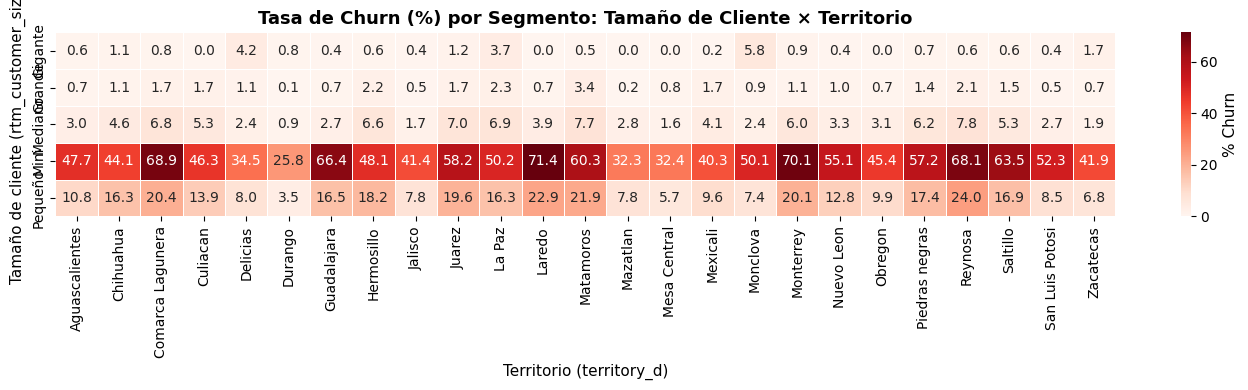

In [23]:
# ──────────────────────────────────────────────────────────────
# HEATMAP DE CHURN POR TAMAÑO DE CLIENTE × TERRITORIO
# Identifica combinaciones de segmento con mayor riesgo de churn.
# ──────────────────────────────────────────────────────────────
pivot = df.pivot_table(
    values='target',
    index='rtm_customer_size_d',
    columns='territory_d',
    aggfunc='mean',
) * 100

print("Tasa de churn (%) por Tamaño × Territorio:")
print(pivot.round(1).to_string())
print()

fig, ax = plt.subplots(figsize=(14, max(4, len(pivot) * 0.7)))
sns.heatmap(
    pivot, annot=True, fmt='.1f',
    cmap='Reds', linewidths=0.5, ax=ax,
    cbar_kws={'label': '% Churn'}
)
ax.set_title('Tasa de Churn (%) por Segmento: Tamaño de Cliente × Territorio',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Territorio (territory_d)')
ax.set_ylabel('Tamaño de cliente (rtm_customer_size_d)')
plt.tight_layout()
plt.show()


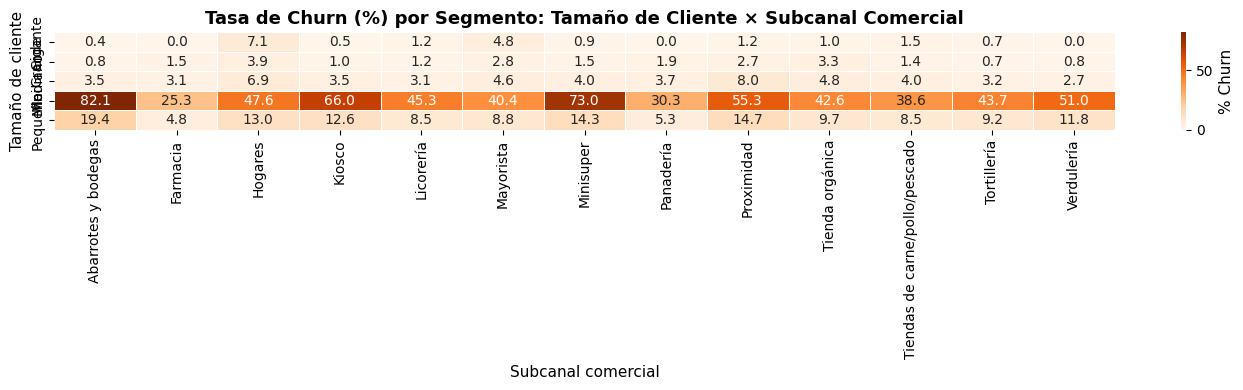

In [24]:
# ──────────────────────────────────────────────────────────────
# SEGMENTOS POR SUBCANAL COMERCIAL
# ──────────────────────────────────────────────────────────────
pivot2 = df.pivot_table(
    values='target',
    index='rtm_customer_size_d',
    columns='comercial_subchannel_d',
    aggfunc='mean',
) * 100

fig, ax = plt.subplots(figsize=(14, max(4, len(pivot2) * 0.7)))
sns.heatmap(
    pivot2, annot=True, fmt='.1f',
    cmap='Oranges', linewidths=0.5, ax=ax,
    cbar_kws={'label': '% Churn'}
)
ax.set_title('Tasa de Churn (%) por Segmento: Tamaño de Cliente × Subcanal Comercial',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Subcanal comercial')
ax.set_ylabel('Tamaño de cliente')
plt.tight_layout()
plt.show()


## 11. Resumen de hallazgos

In [25]:
# ──────────────────────────────────────────────────────────────
# RESUMEN FINAL
# Imprime los principales hallazgos del EDA para referencia rápida.
# ──────────────────────────────────────────────────────────────
print("""
╔══════════════════════════════════════════════════════════════╗
║         RESUMEN: PRINCIPALES HALLAZGOS DEL EDA              ║
╚══════════════════════════════════════════════════════════════╝

DESBALANCE DE CLASES
─────────────────────────────────────────────────
• La tasa global de churn es ~17-20% (1 de cada 5-6 registros).
• A nivel de cliente único el porcentaje puede variar.
• Usar class_weight='balanced' o SMOTE en el modelo.

VARIABLES NUMÉRICAS
─────────────────────────────────────────────────
• Pocos meses activos → mayor riesgo de churn.
  (Clientes recientes o estacionales)
• Pocas transacciones mensuales promedio → señal de baja lealtad.
• Bajo volumen de cajas vendidas → cliente de poco valor.
• Sin coolers o sin puertas → menor "enganche" del cliente.

VARIABLES CATEGÓRICAS
─────────────────────────────────────────────────
• Algunos territorios presentan tasas de churn notablemente más altas.
• El subcanal comercial es un factor diferenciador clave.
• El tamaño del cliente (rtm_customer_size_d) impacta el riesgo.

SIGUIENTE PASO RECOMENDADO (Feature Engineering)
─────────────────────────────────────────────────
→ Tendencia de transacciones en los últimos N meses (slope)
→ Meses consecutivos sin comprar (recency)
→ Ratio cajas/transacciones (ticket promedio mensual)
→ Flag binario: cliente con cooler vs sin cooler
→ Interacción: territorio × tamaño de cliente
""")



╔══════════════════════════════════════════════════════════════╗
║         RESUMEN: PRINCIPALES HALLAZGOS DEL EDA              ║
╚══════════════════════════════════════════════════════════════╝

DESBALANCE DE CLASES
─────────────────────────────────────────────────
• La tasa global de churn es ~17-20% (1 de cada 5-6 registros).
• A nivel de cliente único el porcentaje puede variar.
• Usar class_weight='balanced' o SMOTE en el modelo.

VARIABLES NUMÉRICAS
─────────────────────────────────────────────────
• Pocos meses activos → mayor riesgo de churn.
  (Clientes recientes o estacionales)
• Pocas transacciones mensuales promedio → señal de baja lealtad.
• Bajo volumen de cajas vendidas → cliente de poco valor.
• Sin coolers o sin puertas → menor "enganche" del cliente.

VARIABLES CATEGÓRICAS
─────────────────────────────────────────────────
• Algunos territorios presentan tasas de churn notablemente más altas.
• El subcanal comercial es un factor diferenciador clave.
• El tamaño del cli